## Bayesian Neural Networks with Pyro



## Define and run Markov chain Monte Carlo sampler

To begin with, we can use MCMC to compute an *unbiased estimate* of $p(y|x, \mathcal{D}) = \mathbb{E}_{\theta \sim p(\theta|\mathcal{D})}\big[p(y|x,\theta)\big]$ through Monte Carlo sampling. Specifically, we can approximate $\mathbb{E}_{\theta \sim p(\theta|\mathcal{D})}\big[p(y|x,\theta)\big]$ as follows:
$$\mathbb{E}_{\theta \sim p(\theta|\mathcal{D})}\big[p(y|x,\theta)\big] \approx \frac{1}{N} \sum_{i=1}^{N} p(y|x,\theta_{i}),$$
where $\theta_{i} \sim p(\theta_i|\mathcal{D}) \propto p(\mathcal{D}|\theta)p(\theta)$ are samples drawn from the posterior distribution. Because the normalizing constant is intractable, we require MCMC methods like Hamiltonian Monte Carlo to draw samples from the non-normalized posterior.

Here, we use the No-U-Turn ([NUTS](https://arxiv.org/abs/1111.4246)) kernel.

## Bayesian Neural Network with Gaussian Prior and Likelihood
Our first Bayesian neural network employs a Gaussian prior on the weights and a Gaussian likelihood function for the data. The network is a shallow neural network with one hidden layer.

To be specific, we use the following prior on the weights $\theta$:

$p(\theta) = \mathcal{N}(\mathbf{0}, 10\cdot\mathbb{I}),$ where $\mathbb{I}$ is the identity matrix.

To train the network, we define a likelihood function comparing the predicted outputs of the network with the actual data points:

$p(y_i| x_i, \theta) = \mathcal{N}\big(NN_{\theta}(x_i), \sigma^2\big)$, with prior $\sigma \sim \Gamma(1,1)$.

Here, $y_i$ represents the actual output for the $i$-th data point, $x_i$ represents the input for that data point, $\sigma$ is the standard deviation parameter for the normal distribution and $NN_{\theta}$ is the shallow neural network parameterized by $\theta$. 

Note that we use $\sigma^2$ instead of $\sigma$ in the likelihood function because we use a Gaussian prior on $\sigma$ when performing variational inference and then want to avoid negative values for the standard deviation.

## Define and run Markov chain Monte Carlo sampler

To begin with, we can use MCMC to compute an *unbiased estimate* of $p(y|x, \mathcal{D}) = \mathbb{E}_{\theta \sim p(\theta|\mathcal{D})}\big[p(y|x,\theta)\big]$ through Monte Carlo sampling. Specifically, we can approximate $\mathbb{E}_{\theta \sim p(\theta|\mathcal{D})}\big[p(y|x,\theta)\big]$ as follows:
$$\mathbb{E}_{\theta \sim p(\theta|\mathcal{D})}\big[p(y|x,\theta)\big] \approx \frac{1}{N} \sum_{i=1}^{N} p(y|x,\theta_{i}),$$
where $\theta_{i} \sim p(\theta_i|\mathcal{D}) \propto p(\mathcal{D}|\theta)p(\theta)$ are samples drawn from the posterior distribution. Because the normalizing constant is intractable, we require MCMC methods like Hamiltonian Monte Carlo to draw samples from the non-normalized posterior.

Here, we use the No-U-Turn ([NUTS](https://arxiv.org/abs/1111.4246)) kernel.

## Multi-fidelity Neural Network Architecture
<img src="https://paolo-conti.com/publication/journal-article/featured_hu4fb9bddbb2716143675b6f4d1a4d4b15_400689_720x2500_fit_q75_h2_lanczos_3.webp" alt="drawing" width="400"/>

(proposed in [Ref](https://arxiv.org/pdf/2102.13403))

-------------------------------------------------

## Simulate data
Let's generate noisy observations from a sinusoidal function.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(20)
import pandas as pd
import sys
import os
from sklearn.metrics import mean_squared_error

In [2]:
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from pyro.infer import MCMC, NUTS


In [3]:
version = 'vbnn1.3'
file_in=f'Ge77_rates_CNP_{version}.csv'
if not os.path.exists(f'out/{version}'):
   os.makedirs(f'out/{version}')
   

# Set parameter name/x_labels -> needs to be consistent with data input file
x_labels=['Radius[cm]','Thickness[cm]','NPanels', 'Theta[deg]', 'Length[cm]']
x_labels_out = ['Radius [cm]','Thickness [cm]','NPanels', 'Angle [deg]', 'Length [cm]']

y_err_label_cnp = 'Ge-77_CNP_err'
y_label_sim = 'rGe77[nuc/(kg*yr)]'

# Set parameter boundaries
xmin=[0,0,0,0,0]
xmax=[265,20,360,90,150]

# Set parameter boundaries for aquisition function
xlow=[90,2,4,0,1]
xhigh=[250,15,360,90,150]

# Assign costs
low_fidelity_cost = 1.
high_fidelity_cost = 2000.
n_fidelities = 2
# Set a fixed point in space for drawings
x_fixed = [160, 2, 40, 45, 20]
# number of sigma for error band drawing on prediction
factor=1.

# Get LF noise from file
#with open(f'in/{file_in}') as f:
#    first_line = f.readline()
#LF_noise=np.round(float(first_line.split(' +')[0].split('= ')[1]),3)
LF_noise = 0.028
# Get HF and LF data samples from file

data=pd.read_csv(f'in/{file_in}')
#data=data[[f'Mode', x_labels[0], x_labels[1], x_labels[2], x_labels[3], x_labels[4],y_label_cnp,y_err_label_cnp,y_label_sim]]


In [4]:

x_train_l, x_train_h, y_train_l, y_train_h = ([],[],[],[])
row_h=data.index[data['Mode'] == 1]
row_l=data.index[data['Mode'] == 0]

x_train_hf_sim = data.loc[data['Mode']==1.][x_labels].to_numpy()
y_train_hf_sim = data.loc[data['Mode']==1.][y_label_sim].to_numpy()

x_train_lf_sim = data.loc[data['Mode']==0.][x_labels].to_numpy()
y_train_lf_sim = data.loc[data['Mode']==0.][ y_label_sim].to_numpy()

## Getting started with Pyro

Let's install Pyro now.  You may have to restart the runtime after this step.

In [5]:
class MultiFidelityLFBNN(PyroModule):
    def __init__(self,in_dim=5,hid_dim=64,prior_scale=0.5,out_dim=1):
        self.prior_scale = prior_scale
        super(MultiFidelityLFBNN, self).__init__()

        # Low-fidelity Bayesian network (5 features input)
        self.low_fidelity_layer1 = PyroModule[nn.Linear](in_dim, hid_dim)
        self.low_fidelity_layer1.weight = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim, in_dim]).to_event(2))
        self.low_fidelity_layer1.bias = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim]).to_event(1))
        
        #self.low_fidelity_layer2 = PyroModule[nn.Linear](hid_dim, hid_dim)
        #self.low_fidelity_layer2.weight = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim, hid_dim]).to_event(2))
        #self.low_fidelity_layer2.bias = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim]).to_event(1))

        self.low_fidelity_layer3 = PyroModule[nn.Linear](hid_dim, out_dim)
        self.low_fidelity_layer3.weight = PyroSample(dist.Normal(0., prior_scale).expand([out_dim, hid_dim]).to_event(2))
        self.low_fidelity_layer3.bias = PyroSample(dist.Normal(0., prior_scale).expand([out_dim]).to_event(1))

        # Activation function
        #self.activation = nn.ReLU()
        self.activation = nn.Tanh()

    def forward(self, x, y_lf=None):
        # Low-fidelity network processing
        x = self.activation(self.low_fidelity_layer1(x))
        #x = self.activation(self.low_fidelity_layer2(x))
        mu = self.low_fidelity_layer3(x).squeeze()

        sigma = pyro.sample("sigma_lf", dist.Gamma(self.prior_scale, 1))  # infer the response noise

        with pyro.plate("data_lf", x.shape[0]):
            obs = pyro.sample("obs_lf", dist.Normal(mu, sigma*sigma), obs=y_lf)

        return mu

In [6]:


model_lf = MultiFidelityLFBNN()

# Set Pyro random seed
pyro.set_rng_seed(42)

# Define Hamiltonian Monte Carlo (HMC) kernel
# NUTS = "No-U-Turn Sampler" (https://arxiv.org/abs/1111.4246), gives HMC an adaptive step size
nuts_kernel_lf = NUTS(model_lf, jit_compile=False)  # jit_compile=True is faster but requires PyTorch 1.6+

# Define MCMC sampler, get 50 posterior samples
mcmc_lf = MCMC(nuts_kernel_lf, num_samples=200)

# Convert data to PyTorch tensors
x_train_lf = torch.from_numpy(x_train_lf_sim).float()
y_train_lf = torch.from_numpy(y_train_lf_sim).float()

# Run MCMC
mcmc_lf.run(x_train_lf, y_train_lf)

Sample: 100%|██████████| 400/400 [36:59,  5.55s/it, step size=1.15e-03, acc. prob=0.894]


In [7]:
class MultiFidelityHFBNN(PyroModule):
    def __init__(self, in_dim=5,hid_dim=64,prior_scale=0.5,out_dim=1):
        super(MultiFidelityHFBNN, self).__init__()
        self.prior_scale = prior_scale
        # Low-fidelity Bayesian network (5 features input)
        self.high_fidelity_layer1 = PyroModule[nn.Linear](in_dim+out_dim, hid_dim)
        self.high_fidelity_layer1.weight = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim, in_dim+out_dim]).to_event(2))
        self.high_fidelity_layer1.bias = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim]).to_event(1))
        
        #self.high_fidelity_layer2 = PyroModule[nn.Linear](hid_dim, hid_dim)
        #self.high_fidelity_layer2.weight = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim, hid_dim]).to_event(2))
        #self.high_fidelity_layer2.bias = PyroSample(dist.Normal(0., prior_scale).expand([hid_dim]).to_event(1))

        self.high_fidelity_layer3 = PyroModule[nn.Linear](hid_dim, out_dim)
        self.high_fidelity_layer3.weight = PyroSample(dist.Normal(0., prior_scale).expand([out_dim, hid_dim]).to_event(2))
        self.high_fidelity_layer3.bias = PyroSample(dist.Normal(0., prior_scale).expand([out_dim]).to_event(1))

        # Activation function
        #self.activation = nn.ReLU()
        self.activation = nn.Tanh()

    def forward(self, lf_model, x, y_hf=None):
        # Low-fidelity network processing
        y_lf = lf_model(x)
        y_lf = y_lf.unsqueeze(1)

        # Concatenate low-fidelity output with high-fidelity input
        combined_input = torch.cat([x, y_lf], dim=1)

        # High-fidelity network processing
        x = self.activation(self.high_fidelity_layer1(combined_input))
        #x = self.activation(self.high_fidelity_layer2(x))
        mu = self.high_fidelity_layer3(x).squeeze()

        # Sample observation noise and return the final high-fidelity prediction
        sigma = pyro.sample("sigma_hf", dist.Gamma(self.prior_scale, 1))
        
        with pyro.plate("data_hf", x.shape[0]):
            obs = pyro.sample("obs_hf", dist.Normal(mu, sigma*sigma), obs=y_hf)
        
        return mu

In [8]:
model_hf = MultiFidelityHFBNN()

In [9]:
# Set Pyro random seed
pyro.set_rng_seed(42)

# Define Hamiltonian Monte Carlo (HMC) kernel
# NUTS = "No-U-Turn Sampler" (https://arxiv.org/abs/1111.4246), gives HMC an adaptive step size
nuts_kernel_hf = NUTS(model_hf, jit_compile=False)  # jit_compile=True is faster but requires PyTorch 1.6+

# Define MCMC sampler, get 50 posterior samples
mcmc_hf = MCMC(nuts_kernel_hf, num_samples=200)

# Convert data to PyTorch tensors
x_train_hf = torch.from_numpy(x_train_hf_sim).float()
y_train_hf = torch.from_numpy(y_train_hf_sim).float()

# Run MCMC
mcmc_hf.run(model_lf, x_train_hf, y_train_hf)

Sample: 100%|██████████| 400/400 [28:00,  4.20s/it, step size=1.19e-03, acc. prob=0.678]


In [10]:
from pyro.infer import Predictive

data=pd.read_csv("./in/hf_validation_data_v1.2.csv")
x_test_hf_sim = torch.from_numpy(data.loc[data['Mode']==1.][x_labels].to_numpy()).float()
y_test_hf_sim = torch.from_numpy(data.loc[data['Mode']==1.][y_label_sim].to_numpy()).float()

predictive_lf = Predictive(model=model_lf, posterior_samples=mcmc_lf.get_samples())
#preds = predictive_lf(x_test_hf_sim)

predictive_hf = Predictive(model=model_hf, posterior_samples=mcmc_hf.get_samples())
preds = predictive_hf(model_lf,x_test_hf_sim)
#

In [11]:
def plot_predictions(preds, x, y_true):
    y_pred = preds['obs_hf'].T.detach().numpy().mean(axis=1)
    y_std = preds['obs_hf'].T.detach().numpy().std(axis=1)

    fig, ax = plt.subplots(figsize=(12, 3.5))
    plt.ylim(0.01,10.)
    plt.xlabel('HF Simulation Trial Number')
    plt.ylabel(r'$y_{raw}$')
    plt.yscale('log')
    ax.fill_between(x, y_pred - 3 * y_std, y_pred + 3 * y_std, color="coral",alpha=0.2, label=r'$\pm 2\sigma$')
    ax.fill_between(x, y_pred - 2 * y_std, y_pred + 2 * y_std, color="yellow",alpha=0.2, label=r'$\pm 2\sigma$')
    ax.fill_between(x, y_pred - 1 * y_std, y_pred + 1 * y_std, color="green",alpha=0.2, label=r'RESuM $\pm 1\sigma$')
    ax.plot(x, y_pred, '-', linewidth=1, color="#408765", label="predictive mean")
    ax.plot(x, y_true,'.',color="black", label="HF Validation Data")
    handles, labels = plt.gca().get_legend_handles_labels()
    order = [3,2,1,0]
    plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc=9, bbox_to_anchor=(0.665,1.),ncol=5)
    plt.savefig(f'out/{version}/model-validation_{version}.pdf')

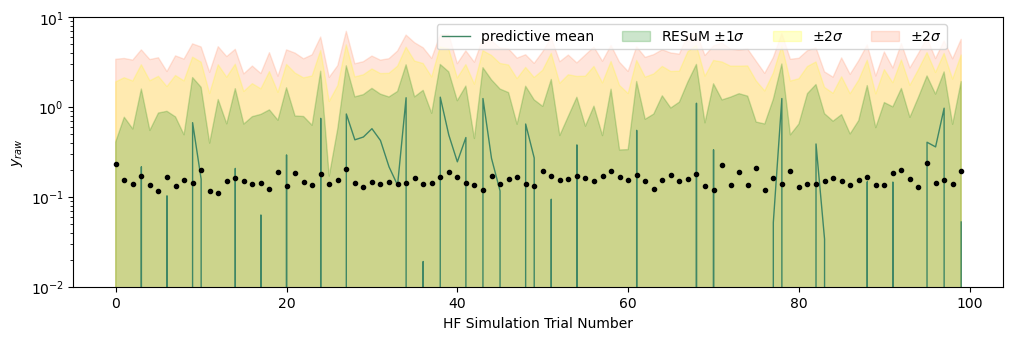

In [12]:
x = np.arange(len(y_test_hf_sim))
plot_predictions(preds, x, y_test_hf_sim)

In [13]:
def model_validation(preds, y_true):
        y = y_true.detach().numpy()
        y_pred = preds['obs_hf'].T.detach().numpy().mean(axis=1)
        y_std = preds['obs_hf'].T.detach().numpy().std(axis=1)

        counter_1sigma = 0
        counter_2sigma = 0
        counter_3sigma = 0
        MSE=0
        NMSE=0
        MAE=0
        MSSE=0
        for i in range(len(y)):
                if (y[i] < y_pred[i]+y_std[i]) and (y[i] > y_pred[i]-y_std[i]):
                        counter_1sigma += 1
                if (y[i] < y_pred[i]+2*y_std[i]) and (y[i] > y_pred[i]-2*y_std[i]):
                        counter_2sigma += 1
                if (y[i] < y_pred[i]+3*y_std[i]) and (y[i] > y_pred[i]-3*y_std[i]):
                        counter_3sigma += 1
                
                MAE +=np.abs(y[i]-y_pred[i])
                MSE +=pow(y[i]-y_pred[i],2)
                NMSE +=np.abs((y[i]-y_pred[i])/y_std[i])
                MSSE +=pow((y[i]-y_pred[i])/y_std[i],2)

        #if (counter_2sigma/len(y)*100.==100. and counter_3sigma/len(y)*100.==100. and counter_1sigma/len(y)*100.<68.):
        #        counter_1sigma=counter_2sigma=counter_3sigma=0.
        percentage_1sigma=counter_1sigma/len(y)*100.
        percentage_2sigma=counter_2sigma/len(y)*100.
        percentage_3sigma=counter_3sigma/len(y)*100.
        print("1 sigma: ", percentage_1sigma," %" )
        print("2 sigma: ", percentage_2sigma," %" )
        print("3 sigma: ", percentage_3sigma," %" )

        MAE=MAE/len(y)
        mse = mean_squared_error(y,y_pred, squared=True)
        NMSE=NMSE/len(y)
        MSSE=MSSE/len(y)
        return [percentage_1sigma,percentage_2sigma,percentage_3sigma,MAE,NMSE,mse,MSSE]

In [14]:
cov=model_validation(preds, y_test_hf_sim)
cov=[cov]

1 sigma:  100.0  %
2 sigma:  100.0  %
3 sigma:  100.0  %


In [15]:
# Open a file in write mode
with open(f"out/{version}/latex_table_{version}.tex", "w") as file:
    # Write the LaTeX document header
    file.write("\\documentclass{article}\n")
    file.write("\\usepackage{booktabs}\n")  # For better-looking tables
    file.write("\\begin{document}\n")
    file.write("\\begin{table}[ht]\n")
    file.write("\\centering\n")
    file.write("\\begin{tabular}{|c|c|c|c|c|c|c|c|c|c|c|}\n")
    file.write("\\hline\n")
    file.write("Model & no. HF & no. LF & $1\sigma$ & $1\sigma$ & $3\sigma$ & MAE & NMSE & MSE & MSSE & CPUh\\\\ \\hline\n")

    # Write each row of the table
    for i, row in enumerate(cov):
        file.write(f"MF-BNN & 7 & 307 & {''.join([f'{x:.3f} & ' for x in cov[i]])} \\\ \hline\n")

    # Write the LaTeX document footer
    file.write("\\end{tabular}\n")
    file.write("\\caption{MF-BNN}\n")
    file.write("\\label{tab:example}\n")
    file.write("\\end{table}\n")
    file.write("\\end{document}\n")